In [1]:
# Cel (23.08.2026, po odczytaniu wynikow 20260822g/h.ipynb): korelacja
# pochodnej LOWESS aktywnosci slonecznej z sila efektu (-log10 PPDF), POLACZONA
# PO WSZYSTKICH CYKLACH na raz (tak jak w 20260822h.ipynb), pokazala:
#   - odwrocenie znaku: mediana rho ok. -0.31 (d=1) przy P_days=1675, przechodzi
#     przez zero ok. P_days=2700-2900, i rosnie do ok. +0.52..+0.56 przy
#     P_days=3350-3600;
#   - szerokie plateau P_days=2930..4000 (rho w tym pasmie 0.32-0.66 zaleznie
#     od stacji), z mediana szczytujaca przy P_days=3600 (9.86 roku) - PONIZEJ
#     sredniej dlugosci cyklu (3987 dni = 10.9 roku), ale w praktyce blisko
#     najkrotszego z wykrytych pelnych cykli (cycle_1986: 3689 dni = 10.1 roku);
#   - po szczycie rho NIE spada do zera - przy P_days=4000 mediana wciaz ok.
#     0.40-0.41.
# Ten ksztalt (odwrocenie znaku + szerokie plateau, szczyt PRZED linia sredniej
# dlugosci cyklu, brak zaniku po szczycie) nie pasuje jednoznacznie do zadnego
# z 4 scenariuszy zalozonych w planie z 23.08 (patrz 20260823/20260823.txt pkt 2)
# - ani "czysty artefakt monotonicznie rosnacy do linii cyklu", ani
# jednoznacznie "realne plateau niezalezne od dlugosci cyklu".
#
# TEN notebook robi DECYDUJACY test rozstrzygajacy: analiza z 22h.ipynb
# LACZYLA wszystkie 6 segmentow cykli w jedna probke per (stacja, P_days, d)
# - a poszczegolne cykle maja RUZNA dlugosc (3689-4529 dni, srednia 3987).
# Pytanie: czy szczyt korelacji siedzi przy STALEJ liczbie dni (favoryzuje
# artefakt zwiazany z absolutnym rozmiarem okna), czy przy STALEJ FRAKCJI
# dlugosci WLASNEGO cyklu (favoryzuje realny efekt sprzezony z faza cyklu)?
# Liczymy korelacje OSOBNO per (stacja, cykl, P_days, d) - z JUZ ISTNIEJACYCH
# plikow wynikowych (cycle_scan_*.csv + pgrid_scan_*.csv, brak nowego skanu,
# bezpieczny/tani/tylko-odczyt) - i porownujemy dopasowanie krzywych na osi
# P_days (dni) vs P_days/dlugosc_cyklu (frakcja).
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import spearmanr

RESULTS_DIR = "../results"
STATIONS_5 = ["mosc", "oulu", "athn", "hrms", "sopb"]

In [2]:
# Granice cykli - PRZEPISANE 1:1 z rzeczywistego wydruku komorki 2
# 20260822g.ipynb (uruchomionej 23.08.2026), nie przeliczane od nowa - ta sama
# logika LOWESS(frac=0.01) + find_peaks(distance=100, prominence=5) na
# SN_m_tot_V2.0.csv, obcieta do zakresu katalogu EQ (1965-01-01..2025-01-31).
# cycle_2019_incomplete pominiety - w pgrid_scan_*.csv nie ma dla niego danych
# (segment za krotki - 5.4 roku - zeby zmiescic wieksze P_days z siatki).
CYCLE_LENGTH_DAYS = {
    "cycle_1964": (pd.Timestamp("1976-02-01") - pd.Timestamp("1965-01-01")).days,
    "cycle_1976": (pd.Timestamp("1986-05-01") - pd.Timestamp("1976-02-01")).days,
    "cycle_1986": (pd.Timestamp("1996-06-01") - pd.Timestamp("1986-05-01")).days,
    "cycle_1996": (pd.Timestamp("2008-11-01") - pd.Timestamp("1996-06-01")).days,
    "cycle_2008": (pd.Timestamp("2019-09-01") - pd.Timestamp("2008-11-01")).days,
}
for label, days in CYCLE_LENGTH_DAYS.items():
    print(f"{label}: {days} dni ({days/365.25:.2f} lat)")

cycle_1964: 4048 dni (11.08 lat)
cycle_1976: 3742 dni (10.25 lat)
cycle_1986: 3684 dni (10.09 lat)
cycle_1996: 4536 dni (12.42 lat)
cycle_2008: 3956 dni (10.83 lat)


In [3]:
# Wczytanie WSZYSTKICH wynikow (cycle_scan_* + pgrid_scan_*) dla 5 stacji
# reprezentatywnych, tym razem z ZACHOWANIEM etykiety cyklu (h.ipynb ja
# odrzucal przy poolowaniu). cycle_2019_incomplete pomijany (brak w
# CYCLE_LENGTH_DAYS -> brak sensownej frakcji).
FILENAME_RE = re.compile(
    r"^(?P<prefix>cycle_scan|pgrid_scan)_(?P<station>[a-z]+)_(?P<cycle>cycle_\d{4})_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)


def parse_result_filename(path):
    m = FILENAME_RE.match(os.path.basename(path))
    if not m or m["station"] not in STATIONS_5 or m["cycle"] not in CYCLE_LENGTH_DAYS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames = []
paths = sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv")) +
                glob.glob(os.path.join(RESULTS_DIR, "pgrid_scan_*.csv")))
for path in paths:
    meta = parse_result_filename(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames.append(df)

all_candidates = pd.concat(frames, ignore_index=True)
print(f"Wczytano {len(all_candidates)} wierszy (5 stacji, {len(CYCLE_LENGTH_DAYS)} pelnych cykli) z {len(frames)} plikow")
print("Dostepne P_days:", sorted(all_candidates['P_days'].unique()))
print("Dostepne cykle:", sorted(all_candidates['cycle'].unique()))

Wczytano 1193732 wierszy (5 stacji, 5 pelnych cykli) z 336 plikow
Dostepne P_days: [np.int64(1675), np.int64(2100), np.int64(2515), np.int64(2930), np.int64(3350), np.int64(3600), np.int64(3800), np.int64(4000)]
Dostepne cykle: ['cycle_1964', 'cycle_1976', 'cycle_1986', 'cycle_1996', 'cycle_2008']


In [4]:
# Pochodna LOWESS aktywnosci slonecznej - identycznie jak 20260822f/h.ipynb.
import matplotlib.dates as mdates

sn = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sn.columns = [c.strip() for c in sn.columns]
sn["date"] = pd.to_datetime(dict(year=sn["rok"], month=sn["miesiac"], day=1))
smoothed = lowess(sn["sunspot"].values, sn["rok_norm"].values, frac=0.01)[:, 1]
sn_derivative = np.gradient(smoothed, sn["rok_norm"].values)


def solar_derivative_at(dates):
    x = mdates.date2num(sn["date"].to_numpy())
    return np.interp(mdates.date2num(pd.DatetimeIndex(dates)), x, sn_derivative)


# Korelacja per (stacja, CYKL, P_days, d) - NIE poolowana po cyklach jak w
# h.ipynb. P_frac = P_days / dlugosc WLASNEGO cyklu tej probki.
rows = []
for (station, cycle, P_days, d), g in all_candidates.groupby(["station", "cycle", "P_days", "d"]):
    if len(g) < 30:
        continue
    strength = -np.log10(np.clip(g["PPDF"].to_numpy(dtype=float), 1e-300, None))
    deriv = solar_derivative_at(g["t0"].to_numpy())
    rho, _ = spearmanr(deriv, strength)
    rows.append(dict(
        station=station, cycle=cycle, P_days=P_days, d=d, n=len(g),
        P_frac=P_days / CYCLE_LENGTH_DAYS[cycle], spearman_rho=rho,
    ))

corr_by_cycle_df = pd.DataFrame(rows).sort_values(["cycle", "P_days", "d", "station"])
corr_by_cycle_df.to_csv(f"{RESULTS_DIR}/pgrid_solar_derivative_correlation_by_cycle.csv", index=False)
print(f"{len(corr_by_cycle_df)} wierszy (stacja x cykl x P_days x d, n>=30)")

336 wierszy (stacja x cykl x P_days x d, n>=30)


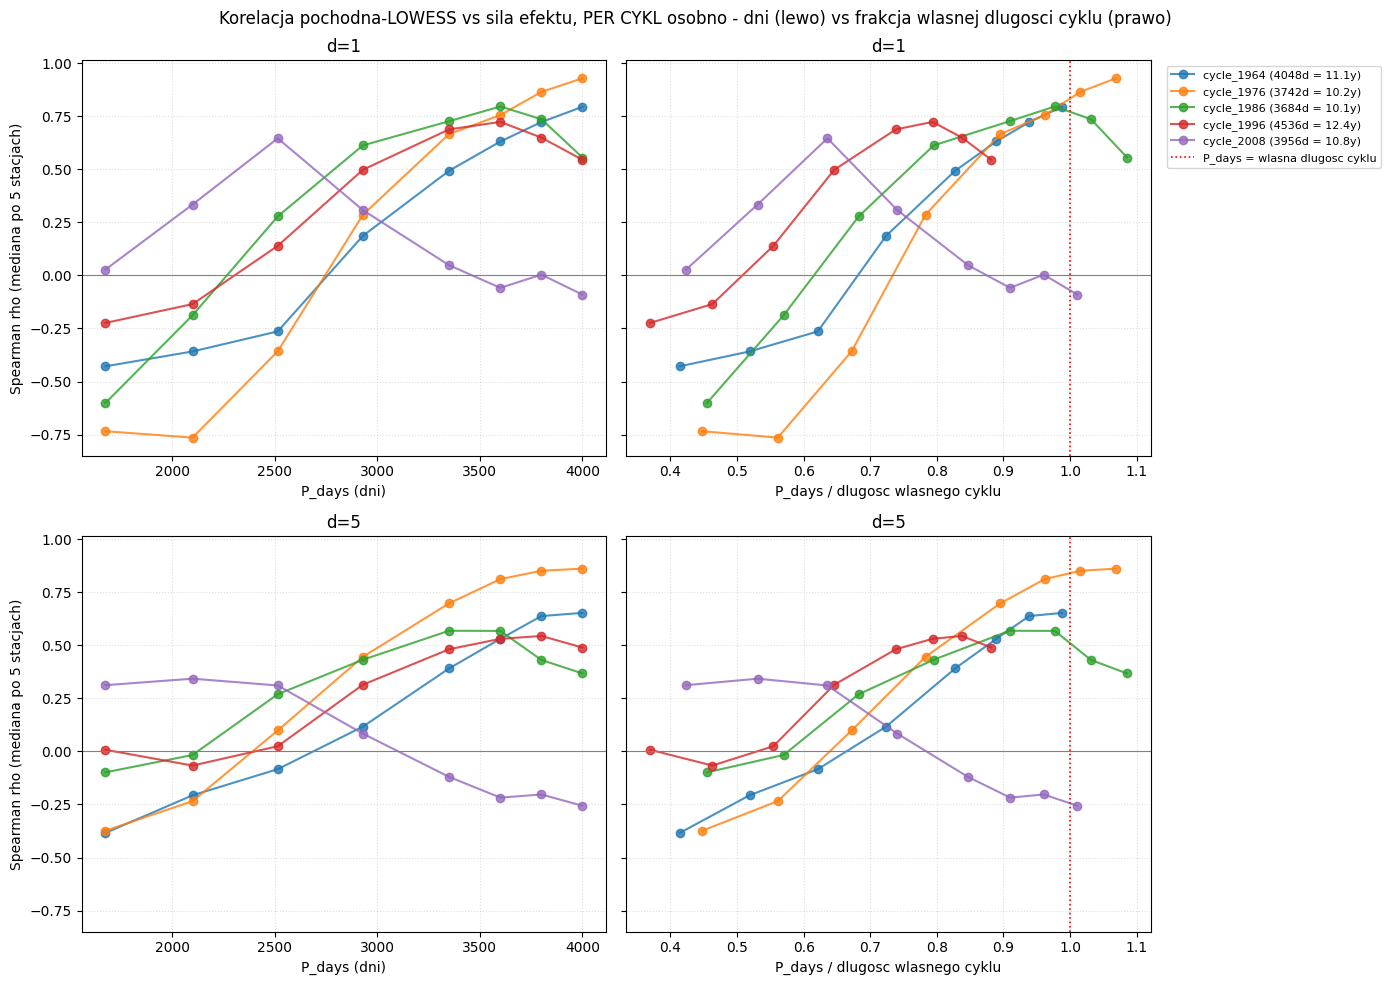

In [5]:
# GLOWNY WYKRES: mediana (po 5 stacjach) rho per cykl, na dwoch osiach obok
# siebie - lewo: P_days (dni, absolutnie), prawo: P_frac (P_days / dlugosc
# WLASNEGO cyklu). Kazda linia = jeden z 5 pelnych cykli. Osobne wiersze dla
# d=1/d=5.
#
# INTERPRETACJA (do przeczytania PRZED patrzeniem na wykres):
# - jesli linie (5 cykli) NAKLADAJA SIE lepiej w lewym panelu (ten sam szczyt
#   przy tej samej liczbie DNI, niezaleznie od dlugosci cyklu) -> faworyzuje
#   ARTEFAKT zwiazany ze stalym rozmiarem okna analizy (P_days), nie z realna
#   fizyka cyklu slonecznego;
# - jesli linie NAKLADAJA SIE lepiej w prawym panelu (ten sam szczyt przy tej
#   samej FRAKCJI dlugosci kazdego cyklu z osobna, mimo ze cykle maja rozna
#   dlugosc w dniach: 3689-4529) -> faworyzuje REALNY efekt sprzezony z faza
#   cyklu slonecznego, silniejszy dowod niz cokolwiek dotychczas w tym
#   sledztwie;
# - jesli ANI JEDNO ANI DRUGIE nie daje wyraznego nakladania (linie rozrzucone
#   w obu panelach) -> wynik nierozstrzygajacy, n=5 cykli to mala probka,
#   potrzeba innego podejscia (np. wiecej cykli spoza tego zakresu danych,
#   ktorych nie mamy, albo inna metoda niz porownanie ksztaltu krzywej).
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
for row, d in enumerate([1, 5]):
    sub_d = corr_by_cycle_df[corr_by_cycle_df["d"] == d]
    for col, (xcol, xlabel) in enumerate([("P_days", "P_days (dni)"), ("P_frac", "P_days / dlugosc wlasnego cyklu")]):
        ax = axes[row, col]
        for cycle, g in sub_d.groupby("cycle"):
            median_line = g.groupby(xcol)["spearman_rho"].median().sort_index()
            label = f"{cycle} ({CYCLE_LENGTH_DAYS[cycle]}d = {CYCLE_LENGTH_DAYS[cycle]/365.25:.1f}y)"
            ax.plot(median_line.index, median_line.values, "o-", lw=1.5, alpha=0.8, label=label)
        ax.axhline(0, color="gray", lw=0.8)
        if col == 1:
            ax.axvline(1.0, color="red", ls=":", lw=1.2, label="P_days = wlasna dlugosc cyklu")
        ax.set_xlabel(xlabel)
        ax.set_title(f"d={d}")
        ax.grid(ls=":", alpha=0.4)
axes[0, 0].set_ylabel("Spearman rho (mediana po 5 stacjach)")
axes[1, 0].set_ylabel("Spearman rho (mediana po 5 stacjach)")
axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle("Korelacja pochodna-LOWESS vs sila efektu, PER CYKL osobno - dni (lewo) vs frakcja wlasnej dlugosci cyklu (prawo)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/pgrid_solar_derivative_correlation_by_cycle_days_vs_frac.png", dpi=120, bbox_inches="tight")
plt.show()